# PS3: Các chỉ số giúp đánh giá việc phát triển thị trường theo khu vực

**Yêu cầu của đề:** Đưa ra các chỉ số thực tế làm cơ sở để ban giám đốc thẩm định tính hiệu quả của chiến lược phát triển thị trường theo vùng địa lý hiện tại.

## 1. Yêu cầu

Nhóm dùng các số liệu để xem tình hình kinh doanh của từng **Region (vùng)**. Region của đơn hàng được xác định qua mã ZIP. Sau khi ghép dữ liệu, mỗi dòng tương ứng với một đơn hàng.

Bài phân tích trả lời các câu hỏi:

1. Mỗi vùng có bao nhiêu doanh thu, đơn hàng và khách hàng?
2. Trung bình một đơn hàng hoặc một khách hàng mang lại bao nhiêu doanh thu?
3. Có bao nhiêu tiền được hoàn lại và bao nhiêu đơn bị trả hàng?
4. Doanh thu, số đơn và số khách tăng hay giảm qua từng năm?
5. Từ kết quả đó, từng vùng cần chú ý hoặc cải thiện điều gì?


## 2. Đọc dữ liệu

Sử dụng bốn bảng: đơn hàng (`orders`), địa chỉ (`geography`), thanh toán (`payments`) và trả hàng (`returns`).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.2f}".format

orders = pd.read_csv("../../SilverData/orders_silver.csv")
geography = pd.read_csv("../../SilverData/geography_silver.csv")
payments = pd.read_csv("../../SilverData/payments_silver.csv")
returns = pd.read_csv("../../SilverData/returns_silver.csv")

orders["order_date"] = pd.to_datetime(orders["order_date"])

print("Khoảng ngày:", orders["order_date"].min().date(), "đến", orders["order_date"].max().date())
print("Orders:", orders.shape)
print("Geography:", geography.shape)
print("Payments:", payments.shape)
print("Returns:", returns.shape)

Khoảng ngày: 2012-07-04 đến 2022-12-31
Orders: (646945, 9)
Geography: (39948, 4)
Payments: (646945, 4)
Returns: (39939, 7)


## 3. Tính doanh thu sau khi trừ tiền hoàn

- Một đơn có thể có nhiều dòng trả hàng. Cộng tiền hoàn của từng đơn trước khi ghép bảng để tránh tính lặp doanh thu.
- Chỉ lấy đơn `delivered` (đã giao) và `returned` (đã trả hàng).
- Đơn đã trả hàng nhưng thiếu thông tin tiền hoàn được loại khỏi phần tính toán.
- Đơn đã giao không có thông tin hoàn tiền được tính tiền hoàn bằng 0.
- **Doanh thu thuần = tiền thanh toán − tiền hoàn.**
- Nếu tiền hoàn lớn hơn tiền thanh toán, vẫn giữ đơn theo cách làm đã thống nhất. Khi đó doanh thu thuần của đơn sẽ âm. Chưa có dữ liệu để xác nhận phần tiền vượt là tiền đền bù.

Tiền hoàn được trừ vào năm đặt hàng của đơn đó. Ví dụ: đơn đặt năm 2021 và hoàn tiền năm 2022 thì bài này trừ tiền hoàn vào doanh thu của đơn năm 2021.

In [2]:
refund_by_order = (
    returns.groupby("order_id")["refund_amount"]
    .sum(min_count=1)
    .reset_index(name="total_refund")
)

df = orders.merge(
    geography[["zip", "region"]], on="zip", how="left", validate="many_to_one"
)
df = df.merge(
    payments[["order_id", "payment_value"]], on="order_id", how="left", validate="one_to_one"
)
df = df.merge(
    refund_by_order, on="order_id", how="left", validate="one_to_one"
)

assert len(df) == len(orders), "Ghép bảng đã làm thay đổi số đơn."
assert df[["region", "order_date", "customer_id", "payment_value"]].notna().all().all(), "Cần kiểm tra dữ liệu thiếu trước khi phân tích."

df_revenue = df.loc[df["order_status"].isin(["delivered", "returned"])].copy()

missing_refund = (
    df_revenue["order_status"].eq("returned")
    & df_revenue["total_refund"].isna()
)
print("Đơn returned thiếu dữ liệu hoàn tiền bị loại:", missing_refund.sum())

df_valid = df_revenue.loc[~missing_refund].copy()
df_valid["total_refund"] = df_valid["total_refund"].fillna(0)
df_valid["net_revenue"] = df_valid["payment_value"] - df_valid["total_refund"]
df_valid["is_returned"] = df_valid["order_status"].eq("returned")
df_valid["year"] = df_valid["order_date"].dt.year

print("Số đơn hợp lệ:", len(df_valid))
print("Số đơn có tiền hoàn vượt thanh toán:", (df_valid["total_refund"] > df_valid["payment_value"]).sum())
print("Tổng doanh thu thuần: {:,.2f}".format(df_valid["net_revenue"].sum()))

Đơn returned thiếu dữ liệu hoàn tiền bị loại: 80
Số đơn hợp lệ: 552778
Số đơn có tiền hoàn vượt thanh toán: 3640
Tổng doanh thu thuần: 12,871,731,922.00


## 4. Chọn thời gian và các chỉ số cần tính

Dữ liệu có từ **04/07/2012 đến 31/12/2022**. Năm 2012 thiếu các tháng đầu năm nên không dùng để so sánh doanh thu giữa các năm.

- Tổng hợp dữ liệu từng năm từ **2013 đến 2022**.
- Tính tăng trưởng từ **2014 đến 2022**: năm 2014 so với 2013, năm 2015 so với 2014, cứ tiếp tục như vậy.
- Dùng **2022**, năm cuối trong dữ liệu, để lập bảng đánh giá chi tiết. Vẫn xem các năm trước để biết kết quả tốt lên hay xấu đi trong thời gian dài.
- Năm 2022 là thời điểm cuối của dữ liệu, không phải năm đang làm bài.

Trong bảng dưới, “đơn” là đơn đã giao hoặc đã trả hàng có đủ thông tin để tính doanh thu.

| Chỉ số trong code | Cách tính và ý nghĩa |
|---|---|
| `net_revenue` | Tổng tiền thanh toán trừ tổng tiền hoàn: doanh thu thuần |
| `order_count` | Số đơn hàng, mỗi mã đơn chỉ đếm một lần |
| `customer_count` | Số khách có đơn trong vùng và trong năm đó, mỗi mã khách chỉ đếm một lần |
| `revenue_per_order` | Doanh thu thuần / số đơn: trung bình một đơn mang lại bao nhiêu doanh thu |
| `revenue_per_customer` | Doanh thu thuần / số khách: trung bình một khách mang lại bao nhiêu doanh thu |
| `orders_per_customer` | Số đơn / số khách: trung bình mỗi khách có bao nhiêu đơn |
| `refund_value_pct` | Tiền hoàn / tiền thanh toán × 100: cứ 100 đồng thanh toán thì hoàn lại bao nhiêu đồng |
| `returned_order_pct` | Số đơn returned / tổng số đơn được phân tích × 100: tỷ lệ đơn trả hàng |
| `revenue_growth_pct` | (Doanh thu năm nay − năm trước) / năm trước × 100 |
| `customer_growth_pct` | (Số khách năm nay − năm trước) / năm trước × 100 |
| `order_growth_pct` | (Số đơn năm nay − năm trước) / năm trước × 100 |

Một khách có thể mua ở nhiều vùng hoặc nhiều năm. Vì vậy, cộng số khách của các vùng hoặc các năm có thể đếm trùng người. Bài này chỉ đếm khách có đơn được phân tích, không đếm toàn bộ khách đã đăng ký.

In [3]:
df_year = df_valid.loc[df_valid["year"].between(2013, 2022)].copy()

annual_kpi = (
    df_year.groupby(["region", "year"], as_index=False)
    .agg(
        gross_payment=("payment_value", "sum"),
        total_refund=("total_refund", "sum"),
        net_revenue=("net_revenue", "sum"),
        order_count=("order_id", "nunique"),
        customer_count=("customer_id", "nunique"),
        returned_orders=("is_returned", "sum")
    )
    .sort_values(["region", "year"])
    .reset_index(drop=True)
)

# Mỗi Region phải có đủ 10 năm để dòng liền trước đúng là năm liền trước.
assert annual_kpi.groupby("region")["year"].nunique().eq(10).all(), "Region thiếu năm; cần xử lý trước khi tính tăng trưởng."

annual_kpi["revenue_per_order"] = (
    annual_kpi["net_revenue"] / annual_kpi["order_count"].replace(0, float("nan"))
)
annual_kpi["revenue_per_customer"] = (
    annual_kpi["net_revenue"] / annual_kpi["customer_count"].replace(0, float("nan"))
)
annual_kpi["orders_per_customer"] = (
    annual_kpi["order_count"] / annual_kpi["customer_count"].replace(0, float("nan"))
)
annual_kpi["refund_value_pct"] = (
    annual_kpi["total_refund"] / annual_kpi["gross_payment"].replace(0, float("nan")) * 100
)
annual_kpi["returned_order_pct"] = (
    annual_kpi["returned_orders"] / annual_kpi["order_count"].replace(0, float("nan")) * 100
)

display(annual_kpi[["region", "year", "net_revenue", "order_count", "customer_count"]])

,region,year,net_revenue,order_count,customer_count
0,Central,2013,"379,467,797.37",18259,10983
1,Central,2014,"415,964,726.67",18406,11011
2,Central,2015,"407,808,208.73",18729,11142
3,Central,2016,"478,872,352.95",19395,11337
4,Central,2017,"435,521,982.78",18299,11004
5,Central,2018,"470,387,765.68",18679,11123
6,Central,2019,"285,970,411.28",10862,7723
7,Central,2020,"272,770,139.15",9420,6979
8,Central,2021,"259,115,662.83",9041,6682
9,Central,2022,"291,077,157.76",9237,6795


## 5. Xem doanh thu, khách hàng và số đơn tăng hay giảm qua từng năm

Sau khi sắp xếp năm tăng dần, `shift(1)` lấy số liệu năm trước của cùng Region.

Ví dụ: doanh thu năm trước là 100, năm nay là 120 thì tăng trưởng là **20%**. Nếu năm nay còn 90 thì tăng trưởng là **−10%**, nghĩa là giảm 10%.

Nếu số liệu năm trước bằng 0 hoặc âm, code không tính phần trăm tăng trưởng và để `NaN` (chưa có giá trị để tính).

In [4]:
previous_revenue = annual_kpi.groupby("region")["net_revenue"].shift(1)
previous_customers = annual_kpi.groupby("region")["customer_count"].shift(1)
previous_orders = annual_kpi.groupby("region")["order_count"].shift(1)

annual_kpi["revenue_growth_pct"] = (
    (annual_kpi["net_revenue"] - previous_revenue)
    / previous_revenue.where(previous_revenue > 0) * 100
)
annual_kpi["customer_growth_pct"] = (
    (annual_kpi["customer_count"] - previous_customers)
    / previous_customers.where(previous_customers > 0) * 100
)
annual_kpi["order_growth_pct"] = (
    (annual_kpi["order_count"] - previous_orders)
    / previous_orders.where(previous_orders > 0) * 100
)

growth_history = annual_kpi.loc[annual_kpi["year"].between(2014, 2022)].copy()
display(growth_history[[
    "region", "year", "net_revenue", "revenue_growth_pct",
    "customer_count", "customer_growth_pct", "order_count", "order_growth_pct"
]])

,region,year,net_revenue,revenue_growth_pct,customer_count,customer_growth_pct,order_count,order_growth_pct
1,Central,2014,"415,964,726.67",9.62,11011,0.25,18406,0.81
2,Central,2015,"407,808,208.73",-1.96,11142,1.19,18729,1.75
3,Central,2016,"478,872,352.95",17.43,11337,1.75,19395,3.56
4,Central,2017,"435,521,982.78",-9.05,11004,-2.94,18299,-5.65
5,Central,2018,"470,387,765.68",8.01,11123,1.08,18679,2.08
6,Central,2019,"285,970,411.28",-39.21,7723,-30.57,10862,-41.85
7,Central,2020,"272,770,139.15",-4.62,6979,-9.63,9420,-13.28
8,Central,2021,"259,115,662.83",-5.01,6682,-4.26,9041,-4.02
9,Central,2022,"291,077,157.76",12.33,6795,1.69,9237,2.17
11,East,2014,"693,612,690.10",13.60,18484,3.06,31576,5.82


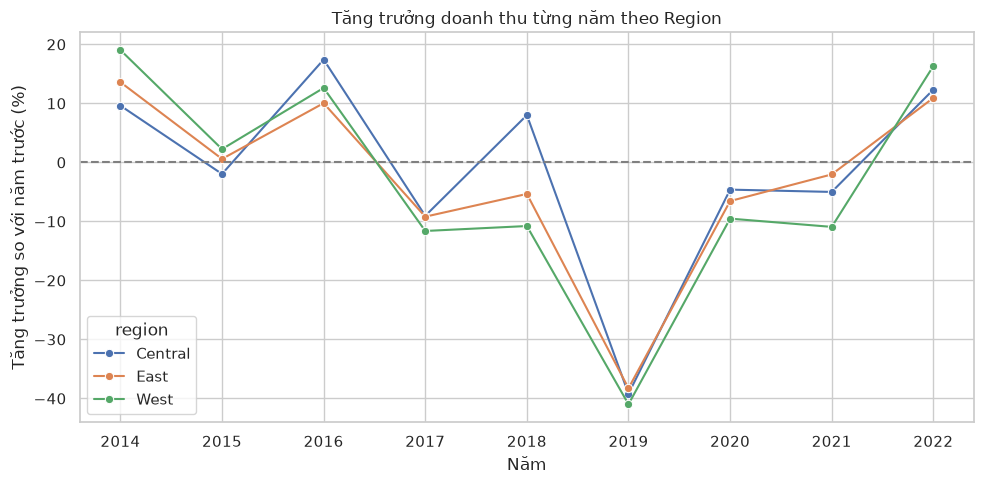

In [5]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=growth_history, x="year", y="revenue_growth_pct", hue="region", marker="o")
plt.axhline(0, color="gray", linestyle="--")
plt.xticks(range(2014, 2023))
plt.title("Tăng trưởng doanh thu từng năm theo Region")
plt.xlabel("Năm")
plt.ylabel("Tăng trưởng so với năm trước (%)")
plt.tight_layout()
plt.show()

### Nhìn lại cả giai đoạn

Bảng dưới so sánh doanh thu năm 2013 với năm 2022, đồng thời đếm số năm doanh thu tăng và giảm trong giai đoạn 2014–2022.

Ví dụ, năm 2022 tăng so với 2021 nhưng vẫn thấp hơn 2013 thì chưa thể nói doanh thu đã tăng tốt trong cả giai đoạn. Những năm không tính được tăng trưởng (`NaN`) không được tính là năm giảm.

In [6]:
growth_history["increased"] = growth_history["revenue_growth_pct"] > 0
growth_history["decreased"] = growth_history["revenue_growth_pct"] < 0

history_summary = (
    growth_history.groupby("region", as_index=False)
    .agg(
        positive_growth_years=("increased", "sum"),
        negative_growth_years=("decreased", "sum"),
        valid_growth_years=("revenue_growth_pct", "count")
    )
)
revenue_2013 = annual_kpi.loc[annual_kpi["year"] == 2013, ["region", "net_revenue"]]
revenue_2022 = annual_kpi.loc[annual_kpi["year"] == 2022, ["region", "net_revenue"]]
history_summary = history_summary.merge(
    revenue_2013.rename(columns={"net_revenue": "revenue_2013"}), on="region"
).merge(
    revenue_2022.rename(columns={"net_revenue": "revenue_2022"}), on="region"
)
history_summary["change_2013_2022_pct"] = (
    (history_summary["revenue_2022"] - history_summary["revenue_2013"])
    / history_summary["revenue_2013"].where(history_summary["revenue_2013"] > 0) * 100
)
display(history_summary)
print("change_2013_2022_pct là thay đổi cả giai đoạn, không phải tăng trưởng mỗi năm.")

,region,positive_growth_years,negative_growth_years,valid_growth_years,revenue_2013,revenue_2022,change_2013_2022_pct
0,Central,4,5,9,"379,467,797.37","291,077,157.76",-23.29
1,East,4,5,9,"610,595,479.33","413,587,814.92",-32.26
2,West,4,5,9,"304,812,649.58","182,234,909.82",-40.21


change_2013_2022_pct là thay đổi cả giai đoạn, không phải tăng trưởng mỗi năm.


## 6. Bảng chỉ số đánh giá năm 2022

Bảng đầu cho biết doanh thu, số đơn, số khách và mức tăng hoặc giảm so với năm 2021.

Bảng tiếp theo cho biết doanh thu trung bình trên đơn, trên khách và tình hình hoàn tiền.

Tỷ trọng doanh thu cho biết mỗi vùng đóng góp bao nhiêu phần trăm doanh thu của công ty. Chỉ số này chưa cho biết công ty chiếm bao nhiêu thị phần so với đối thủ.

In [7]:
kpi_region = annual_kpi.loc[annual_kpi["year"] == 2022].copy()
kpi_region["revenue_share_pct"] = (
    kpi_region["net_revenue"] / kpi_region["net_revenue"].sum() * 100
)
kpi_region = kpi_region.sort_values("net_revenue", ascending=False)

print("Quy mô và tăng trưởng năm 2022:")
display(kpi_region[[
    "region", "net_revenue", "revenue_share_pct", "revenue_growth_pct",
    "order_count", "order_growth_pct", "customer_count", "customer_growth_pct"
]])

print("Doanh thu bình quân và hoàn tiền năm 2022:")
display(kpi_region[[
    "region", "revenue_per_order", "revenue_per_customer", "orders_per_customer",
    "total_refund", "refund_value_pct", "returned_orders", "returned_order_pct"
]])

Quy mô và tăng trưởng năm 2022:


,region,net_revenue,revenue_share_pct,revenue_growth_pct,order_count,order_growth_pct,customer_count,customer_growth_pct
19,East,"413,587,814.92",46.63,10.93,13588,2.03,10256,2.20
9,Central,"291,077,157.76",32.82,12.33,9237,2.17,6795,1.69
29,West,"182,234,909.82",20.55,16.33,6805,8.02,4418,3.51


Doanh thu bình quân và hoàn tiền năm 2022:


,region,revenue_per_order,revenue_per_customer,orders_per_customer,total_refund,refund_value_pct,returned_orders,returned_order_pct
19,East,"30,437.73","40,326.43",1.32,"16,181,144.63",3.77,895,6.59
9,Central,"31,512.09","42,836.96",1.36,"10,852,190.37",3.59,623,6.74
29,West,"26,779.56","41,248.28",1.54,"7,587,980.52",4.00,424,6.23


### So sánh từng vùng với toàn công ty trong năm 2022

- Doanh thu trung bình/đơn của công ty = tổng doanh thu thuần / tổng số đơn.
- Tỷ lệ tiền hoàn của công ty = tổng tiền hoàn / tổng tiền thanh toán × 100.

Sau đó so sánh từng vùng với hai mức này.

Ví dụ: vùng có tỷ lệ tiền hoàn 5%, toàn công ty là 3% thì vùng đó cao hơn **2 điểm phần trăm**. Điều này cho thấy cần xem thêm lý do hoàn tiền, chưa đủ để kết luận vùng đó kinh doanh kém.

In [8]:
df_latest = df_year.loc[df_year["year"] == 2022]

system_revenue_per_order = (
    df_latest["net_revenue"].sum() / df_latest["order_id"].nunique()
)
system_refund_value_pct = (
    df_latest["total_refund"].sum() / df_latest["payment_value"].sum() * 100
)

kpi_region["revenue_per_order_gap_pct"] = (
    (kpi_region["revenue_per_order"] / system_revenue_per_order - 1) * 100
)
kpi_region["refund_gap_pp"] = kpi_region["refund_value_pct"] - system_refund_value_pct

print("Doanh thu/đơn toàn hệ thống: {:,.2f}".format(system_revenue_per_order))
print("Tỷ lệ tiền hoàn toàn hệ thống: {:.2f}%".format(system_refund_value_pct))
display(kpi_region[[
    "region", "revenue_per_order", "revenue_per_order_gap_pct", "refund_value_pct", "refund_gap_pp"
]])

Doanh thu/đơn toàn hệ thống: 29,932.50
Tỷ lệ tiền hoàn toàn hệ thống: 3.76%


,region,revenue_per_order,revenue_per_order_gap_pct,refund_value_pct,refund_gap_pp
19,East,"30,437.73",1.69,3.77,0.01
9,Central,"31,512.09",5.28,3.59,-0.16
29,West,"26,779.56",-10.53,4.00,0.24


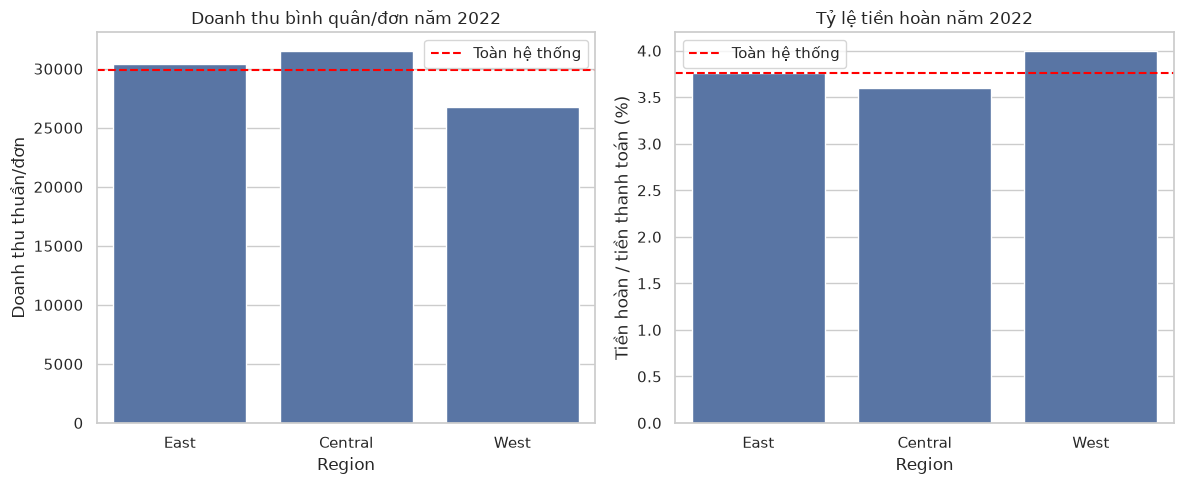

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=kpi_region, x="region", y="revenue_per_order", ax=axes[0])
axes[0].axhline(system_revenue_per_order, color="red", linestyle="--", label="Toàn hệ thống")
axes[0].set_title("Doanh thu bình quân/đơn năm 2022")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Doanh thu thuần/đơn")
axes[0].legend()

sns.barplot(data=kpi_region, x="region", y="refund_value_pct", ax=axes[1])
axes[1].axhline(system_refund_value_pct, color="red", linestyle="--", label="Toàn hệ thống")
axes[1].set_title("Tỷ lệ tiền hoàn năm 2022")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Tiền hoàn / tiền thanh toán (%)")
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Nhận xét và đề xuất cho từng vùng

Phần dưới dùng kết quả đã tính để nhận xét:

- Doanh thu và số khách đang tăng hay giảm?
- Tiền hoàn có chiếm tỷ lệ cao hơn toàn công ty không?
- Doanh thu trung bình một đơn có thấp hơn toàn công ty không?
- Kết quả năm 2022 có khác với tình hình những năm trước không?

Từ đó đưa ra những việc nên kiểm tra hoặc cải thiện. Các đề xuất cần được xem xét thêm trước khi quyết định đầu tư.

In [10]:
for _, row in kpi_region.iterrows():
    print("\nRegion:", row["region"])
    print("Doanh thu 2022: {:,.2f}; đóng góp: {:.2f}%".format(row["net_revenue"], row["revenue_share_pct"]))
    print("Tăng trưởng doanh thu: {:.2f}%; khách hàng: {:.2f}%; số đơn: {:.2f}%".format(
        row["revenue_growth_pct"], row["customer_growth_pct"], row["order_growth_pct"]
    ))
    print("Doanh thu/khách: {:,.2f}; số đơn/khách: {:.2f}".format(
        row["revenue_per_customer"], row["orders_per_customer"]
    ))

    if pd.isna(row["revenue_growth_pct"]) or pd.isna(row["customer_growth_pct"]):
        print("- Thiếu nền so sánh hợp lệ: kiểm tra dữ liệu trước khi nhận xét tăng trưởng.")
    elif row["revenue_growth_pct"] > 0 and row["customer_growth_pct"] > 0:
        print("- Doanh thu và khách hàng cùng tăng: tín hiệu tích cực; kiểm tra chi phí và khả năng duy trì trước khi mở rộng.")
    elif row["revenue_growth_pct"] > 0:
        print("- Doanh thu tăng nhưng khách hàng không tăng: xem xét cơ cấu đơn và khả năng mở rộng tập khách.")
    elif row["customer_growth_pct"] > 0:
        print("- Khách tăng nhưng doanh thu không tăng: kiểm tra giá trị đơn, giảm giá và hoàn tiền.")
    else:
        print("- Doanh thu và khách hàng đều không tăng: rà soát nhu cầu và hoạt động tiếp cận khách.")

    print("- Tiền hoàn: {:.2f}% thanh toán; tỷ lệ đơn returned: {:.2f}%.".format(
        row["refund_value_pct"], row["returned_order_pct"]
    ))
    if row["refund_gap_pp"] > 0:
        print("- Tỷ lệ tiền hoàn cao hơn toàn hệ thống {:.2f} điểm phần trăm: kiểm tra lý do trả hàng và cơ cấu sản phẩm.".format(row["refund_gap_pp"]))
    else:
        print("- Tỷ lệ tiền hoàn không cao hơn toàn hệ thống; tiếp tục theo dõi.")

    if row["revenue_per_order_gap_pct"] < 0:
        print("- Doanh thu/đơn dưới mức toàn hệ thống: xem cơ cấu sản phẩm và nhu cầu địa phương trước khi đề xuất tăng giá trị đơn.")

    history = history_summary.loc[history_summary["region"] == row["region"]].iloc[0]
    print("- Giai đoạn 2014–2022: {} năm tăng, {} năm giảm trên {} năm tính được tăng trưởng.".format(
        int(history["positive_growth_years"]), int(history["negative_growth_years"]), int(history["valid_growth_years"])
    ))
    print("- Doanh thu 2022 so với 2013 thay đổi {:.2f}%; cần đọc cùng lịch sử khi đánh giá kết quả năm cuối.".format(history["change_2013_2022_pct"]))


Region: East
Doanh thu 2022: 413,587,814.92; đóng góp: 46.63%
Tăng trưởng doanh thu: 10.93%; khách hàng: 2.20%; số đơn: 2.03%
Doanh thu/khách: 40,326.43; số đơn/khách: 1.32
- Doanh thu và khách hàng cùng tăng: tín hiệu tích cực; kiểm tra chi phí và khả năng duy trì trước khi mở rộng.
- Tiền hoàn: 3.77% thanh toán; tỷ lệ đơn returned: 6.59%.
- Tỷ lệ tiền hoàn cao hơn toàn hệ thống 0.01 điểm phần trăm: kiểm tra lý do trả hàng và cơ cấu sản phẩm.
- Giai đoạn 2014–2022: 4 năm tăng, 5 năm giảm trên 9 năm tính được tăng trưởng.
- Doanh thu 2022 so với 2013 thay đổi -32.26%; cần đọc cùng lịch sử khi đánh giá kết quả năm cuối.

Region: Central
Doanh thu 2022: 291,077,157.76; đóng góp: 32.82%
Tăng trưởng doanh thu: 12.33%; khách hàng: 1.69%; số đơn: 2.17%
Doanh thu/khách: 42,836.96; số đơn/khách: 1.36
- Doanh thu và khách hàng cùng tăng: tín hiệu tích cực; kiểm tra chi phí và khả năng duy trì trước khi mở rộng.
- Tiền hoàn: 3.59% thanh toán; tỷ lệ đơn returned: 6.74%.
- Tỷ lệ tiền hoàn không c

## 8. Kết luận và những điều chưa thể đánh giá

Các bảng trên giúp ban giám đốc biết từng vùng có bao nhiêu doanh thu, đơn hàng, khách hàng, tiền hoàn và đang tăng hay giảm. Bảng năm 2022 cho biết kết quả mới nhất trong dữ liệu; các năm trước giúp nhìn rõ quá trình thay đổi.

Khi đọc kết quả, cần nhớ:

- Doanh thu cao chưa chắc lãi cao vì chưa tính chi phí.
- Doanh thu trung bình/đơn thấp có thể do vùng đó bán nhiều sản phẩm giá thấp hoặc khách mua ít hơn.
- Tỷ lệ tiền hoàn và tỷ lệ đơn trả hàng khác nhau. Muốn biết nguyên nhân phải xem thêm lý do trả hàng.
- Dữ liệu không có mục tiêu doanh thu, ngân sách và thời điểm bắt đầu chiến lược. Vì vậy, chưa thể kết luận đã đạt kế hoạch hoặc doanh thu tăng là nhờ chiến lược.
- Để đánh giá đầy đủ, cần bổ sung mục tiêu, chi phí và các hoạt động đã thực hiện tại từng vùng.
- Việc loại đơn thiếu tiền hoàn và giữ đơn có tiền hoàn vượt thanh toán có ảnh hưởng đến kết quả; đây là cách xử lý dữ liệu đã thống nhất trong bài.